In [ ]:
import pandas as pd
import seaborn as sns
import sys
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

# Ülesande eesmärk:
# Analüüsida Boston Housing andmestikku ja luua regressioonimudel(id),
# mis ennustavad maja hinda (MEDV).
#
# Üldised juhised:
# - Mudelite loomiseks ja hindamiseks tuleb kasutada scikit-learn’i.
# - Algoritme ei ole vaja implementeerida nullist.

# 1. Andmestiku laadimine
# Laadi andmestik ja tutvu selle struktuuri ning põhiliste statistiliste näitajatega.
# Tee kindlaks, milline veerg on sihtmuutuja.

In [ ]:
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
    'LSTAT', 'MEDV'
]

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/google_colab/housing.csv'
else:
    path = 'housing.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
raw_data = pd.read_csv(
    path,
    header=None,
    delimiter=r"\s+",
    names=column_names
)

In [ ]:
target = 'MEDV'

# 2. Andmete eeltöötlus
# Kontrolli andmestikku:
# - kas esineb puuduvaid või vigaseid väärtusi
# - kas andmetes leidub äärmuslikke või ebamõistlikke väärtusi
# Vajadusel puhasta ja töötle andmeid enne edasist analüüsi.

# TODO: andmete eeltöötlus

In [ ]:
print(raw_data.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

In [ ]:
print(raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [ ]:
print(raw_data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
data = raw_data.copy()

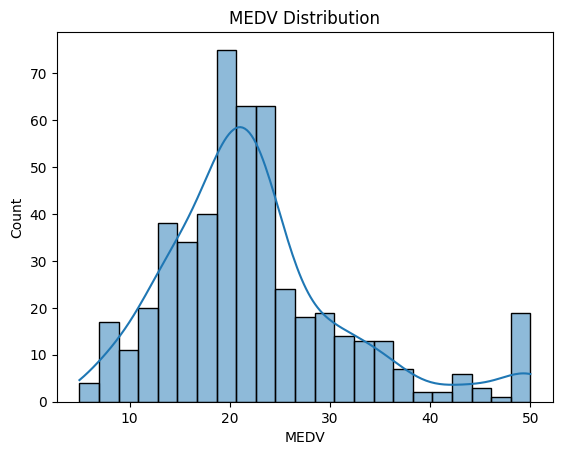

In [ ]:
plt.figure()
sns.histplot(data[target], kde=True)
plt.title("MEDV Distribution")
plt.show()

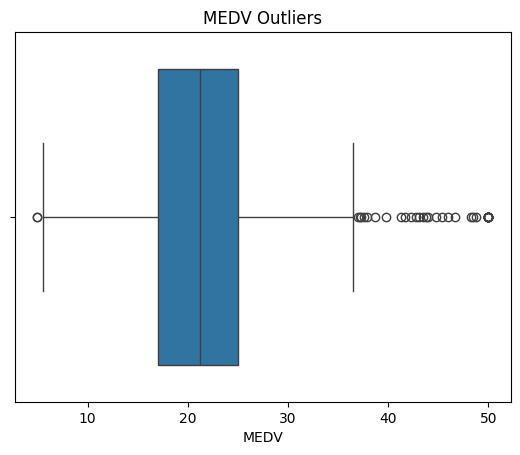

In [ ]:
plt.figure()
sns.boxplot(x=data[target])
plt.title("MEDV Outliers")
plt.show()

# 3. Tunnuste analüüs ja valik
# Analüüsi seoseid tunnuste ja sihtmuutuja vahel.
# Vali tunnused, mida kasutad mudelite treenimiseks.
# Valik peab olema põhjendatud analüüsi tulemustega.

# TODO: tunnuste analüüs

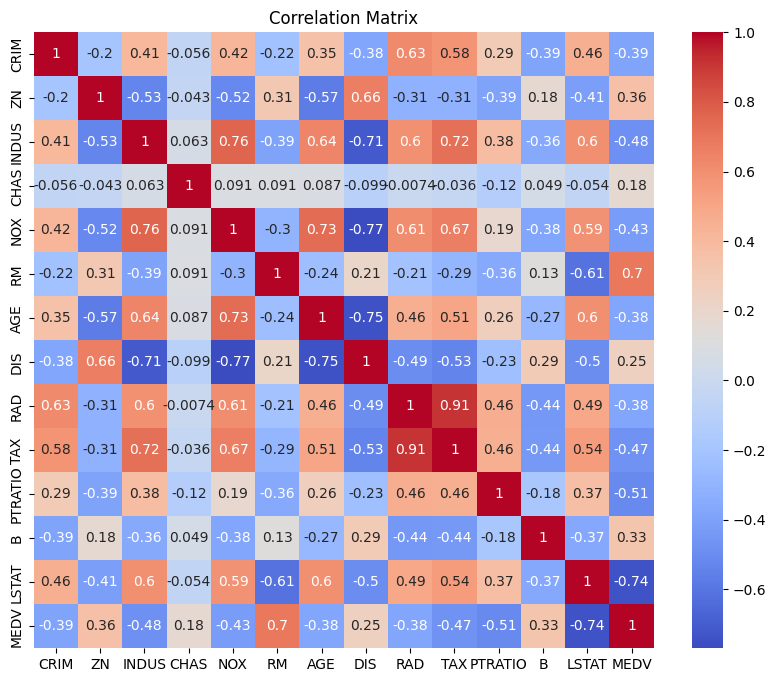

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
selected_features = ['RM', 'LSTAT', 'PTRATIO', 'NOX', 'DIS']

# 4. Treening- ja testandmete jagamine
# Jaga andmed treening- ja testandmeteks.
# Veendu, et mudelit ei hinnata andmetel, millel seda treeniti.

In [ ]:
X = data[selected_features]
y = data[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_scaled = scaler.transform(X)

In [ ]:
X_train = pd.DataFrame(X_train_scaled, columns=selected_features, index=y_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=selected_features, index=y_test.index)
X = pd.DataFrame(X_scaled, columns=selected_features, index=y.index)

# 5. Mudelite treenimine
# Treeni vähemalt kaks erinevat regressioonimudelit.
# Mudelid võivad erineda tunnuste valiku või lähenemise poolest.

In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

LinearRegression()

In [ ]:
model_2 = Lasso(alpha=0.1)
model_2.fit(X_train, y_train)

Lasso(alpha=0.1)

# 6. Mudelite hindamine
# Arvuta mudelite viga kasutades RMSE-d (Root Mean Squared Error).
# Võrdle mudelite tulemusi RMSE väärtuste põhjal ja analüüsi erinevusi.

In [ ]:
pred_1 = model_1.predict(X_test)
pred_2 = model_2.predict(X_test)

In [ ]:
rmse_1 = np.sqrt(mean_squared_error(y_test, pred_1))
rmse_2 = np.sqrt(mean_squared_error(y_test, pred_2))

In [ ]:
models = [
    (model_1, rmse_1),
    (model_2, rmse_2)
]

In [ ]:
print("Linear Regression RMSE:", rmse_1)
print("Lasso Regression RMSE:", rmse_2)

Linear Regression RMSE: 5.019723085624439
Lasso Regression RMSE: 5.007291644686638


In [ ]:
summary = """
Selles töös kasutati Bostoni elamute andmestikku, mille eesmärk oli ennustada
majade mediaanhinda (MEDV) erinevate tunnuste põhjal. Andmestik sisaldab 506
kirjet ja 14 tunnust, mis kirjeldavad näiteks piirkonna kuritegevuse taset,
tubade arvu elamus, maksude suurust ning elanikkonna sotsiaalmajanduslikku
tausta. Andmete uurimisel selgus, et andmestikus ei esinenud puuduvaid väärtusi,
seega ei olnud vaja teha täiendavat andmete puhastamist.

Korrelatsioonianalüüs näitas, et mõned tunnused on majade hinnaga tugevamalt
seotud kui teised. Näiteks tunnus RM (keskmine tubade arv elamus) on positiivses
seoses majade hinnaga, mis tähendab, et rohkemate tubadega majad on üldiselt
kallimad. Samas tunnus LSTAT (madalama sotsiaalmajandusliku staatusega
elanike osakaal) on tugevas negatiivses seoses hinnaga. See viitab sellele,
et piirkondades, kus selliste elanike osakaal on suurem, on majade hinnad
keskmiselt madalamad.

Mudelite treenimiseks valiti mitmed tunnused, millel oli tugevam seos
sihtmuutujaga. Andmed jagati treening- ja testandmeteks ning tunnused
standardiseeriti, et mudelite treenimine oleks stabiilsem. Töös ehitati kaks
mudelit: lineaarne regressioon ning Lasso regressioon. Mõlemat mudelit hinnati
RMSE mõõdiku abil, mis näitab kui suur on mudeli keskmine ennustusviga.

Tulemuste põhjal selgus, et lineaarne regressioon andis veidi parema tulemuse
kui Lasso regressioon. See viitab sellele, et antud andmestiku puhul suudab
tavaline lineaarne mudel juba üsna hästi kirjeldada tunnuste ja majade hinna
vahelist seost. Üldiselt võib järeldada, et majade hinda mõjutavad eriti tugevalt
elamu suurus, piirkonna sotsiaalmajanduslik olukord ning mõningal määral ka
keskkonna- ja infrastruktuuriga seotud tegurid.
"""